### Environment Setup
Import the necessary Python libraries for our exploratory data analysis.
* **Pandas**: For data manipulation and structural analysis.
* **Seaborn** & **Matplotlib**: For generating clean, customized data visualizations.
* **AST**: For safely evaluating strings containing Python list structures.

In [1]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### Data Loading and Cleaning
Here, we load our primary dataset from a CSV file into a Pandas DataFrame. We also perform essential data cleaning steps to prepare for visualization:
* Converting the `job_posted_date` column into a standard datetime format.
* Parsing the `job_skills` column from a string representation of a list into an actual Python list using a lambda function and `ast.literal_eval`.

In [2]:
# Reading the CSV file into a DataFrame
df = pd.read_csv('data_jobs.csv')

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

###  Job Title Distribution
In this section, we analyze the distribution of data-related job titles within the global dataset. We calculate the frequency of each distinct classification and visualize the total counts using a styled horizontal bar chart to identify the most frequent, standard data positions.

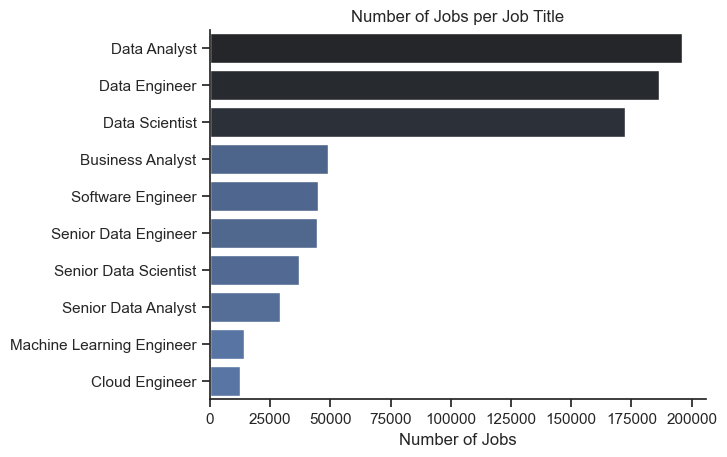

In [ ]:
 # Create a DataFrame with the count of each job title
df_plot = df['job_title_short'].value_counts().reset_index()

sns.set_theme(style='ticks') # Set the theme for the plot
sns.barplot(data=df_plot, x='count', y='job_title_short', hue='count', palette='dark:b_r', legend=False) # Create a bar plot of job titles and their counts
sns.despine()
plt.title('Number of Jobs per Job Title') # Set the title of the plot
plt.xlabel('Number of Jobs')              # Set the x-axis label
plt.ylabel('')                            # Set the y-axis label
plt.show()                                # Display the plot

###  Geographic Distribution of Jobs
To understand where the most opportunities are located, we extract the top 20 countries with the highest number of job postings. The results are displayed in a styled bar plot for quick visual comparison.

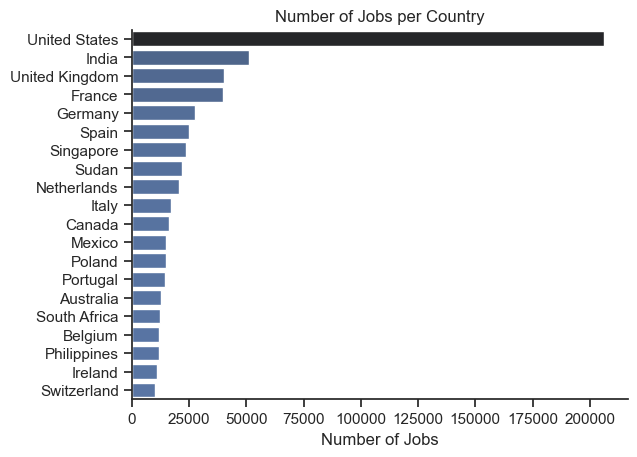

In [ ]:
df_plot = df['job_country'].value_counts().reset_index().head(20)

sns.set_theme(style='ticks')
sns.barplot(data=df_plot, x='count', y='job_country', hue='count', palette='dark:b_r', legend=False) # Create a bar plot of job countries and their counts
sns.despine()
plt.title('Number of Jobs per Country')             # Set the title of the plot
plt.xlabel('Number of Jobs')                        # Set the x-axis label
plt.ylabel('')                                       # Set the y-axis label
plt.show()                                           # Display the plot 

###  Top Hiring Companies
This cell identifies which companies are most actively recruiting data professionals. We extract the top 20 companies by job posting volume and visualize them to highlight major industry players.

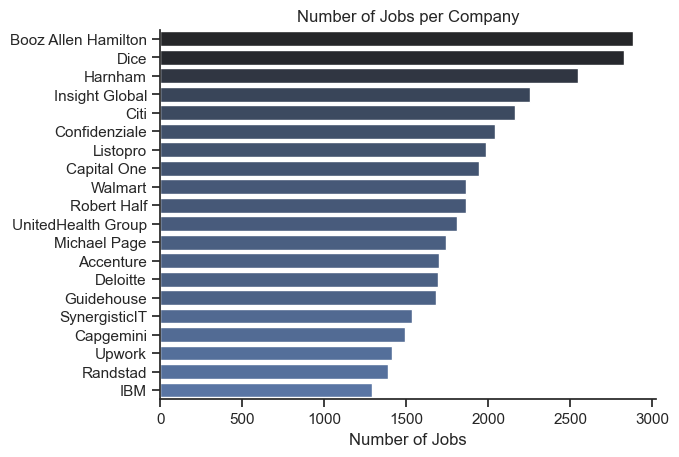

In [ ]:
# Create a DataFrame with the count of each company
df_plot = df['company_name'].value_counts().reset_index()[1:].head(20) 

sns.set_theme(style='ticks')   # Set the theme for the plot
sns.barplot(data=df_plot, x='count', y='company_name', hue='count', palette='dark:b_r', legend=False) # Create a bar plot of companies and their counts
sns.despine()
plt.title('Number of Jobs per Company')     # Set the title of the plot
plt.xlabel('Number of Jobs')                 # Set the x-axis label
plt.ylabel('')                                # Set the y-axis label
plt.show()                                     # Display the plot

###  Job Perks and Requirements Analysis
Finally, we explore the prevalence of specific job characteristics: Work from Home availability, Degree Requirements, and Health Insurance offerings. We generate a 1x3 grid of pie charts to compare the percentage breakdowns of these benefits and requirements across all postings.

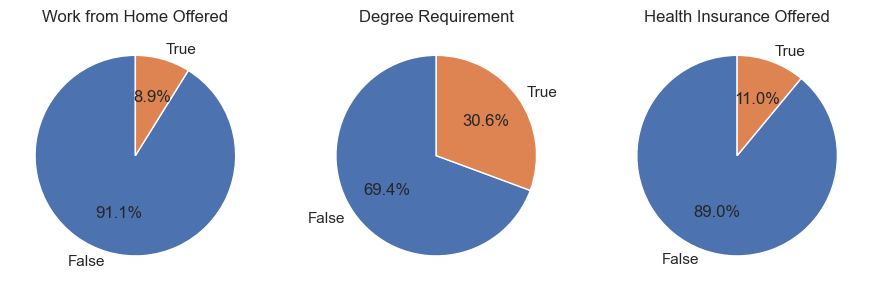

In [ ]:
# Create a dictionary to map the column names to their corresponding titles for the pie charts
dict_column = {
    'job_work_from_home': 'Work from Home Offered',
    'job_no_degree_mention': 'Degree Requirement',
    'job_health_insurance': 'Health Insurance Offered'
}

fig, ax = plt.subplots(1, 3, figsize=(11, 3.5))

for i, (column, title) in enumerate(dict_column.items()): # Loop through the dictionary items to create pie charts for each column
    # Get the value counts to use for both values and labels
    counts = df[column].value_counts()
    ax[i].pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90) # Create a pie chart for each column
    ax[i].set_title(title)

plt.show()

# Exploratory Data Analysis for Data Analysts in India

In [7]:
# Filter for India Data Analyst roles
df_DA_In = df[(df['job_country'] == 'India') & (df['job_title_short'] == 'Data Analyst')]

df_DA_In.head()

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
38,Data Analyst,Data Quality and Governance Analyst 1,India,via Trabajo.org,Full-time,False,India,2023-07-23 13:24:57,False,False,India,NaN,NaN,NaN,"Jones Lang LaSalle IP, Inc","[sql, python, databricks, power bi, excel, wor...","{'analyst_tools': ['power bi', 'excel', 'word'..."
123,Data Analyst,Data Analytics work from home job/internship a...,Anywhere,via LinkedIn,Part-time,True,India,2023-03-07 13:37:56,False,False,India,NaN,NaN,NaN,Inoket Solutions Private Limited,"[sql, excel, word, powerpoint, outlook, power bi]","{'analyst_tools': ['excel', 'word', 'powerpoin..."
159,Data Analyst,Data Analyst,"Hyderabad, Telangana, India",via LinkedIn,Contractor,False,India,2023-11-28 13:12:07,False,False,India,NaN,NaN,NaN,Fusion Plus Solutions Inc,[sql],{'programming': ['sql']}
171,Data Analyst,Data Base work from home job/internship at Mga...,Anywhere,via LinkedIn,Full-time,True,India,2023-01-14 13:11:58,False,False,India,NaN,NaN,NaN,Mgadz Inc,"[sas, sas, sql]","{'analyst_tools': ['sas'], 'programming': ['sa..."
194,Data Analyst,Data Analyst,India,via BeBee India,Full-time,False,India,2023-06-20 13:11:10,False,False,India,NaN,NaN,NaN,QuEST Global Services Pte. Ltd,"[python, sql, excel, ms access, powerpoint]","{'analyst_tools': ['excel', 'ms access', 'powe..."


Filter for India Data Analyst roles with a bar chart.

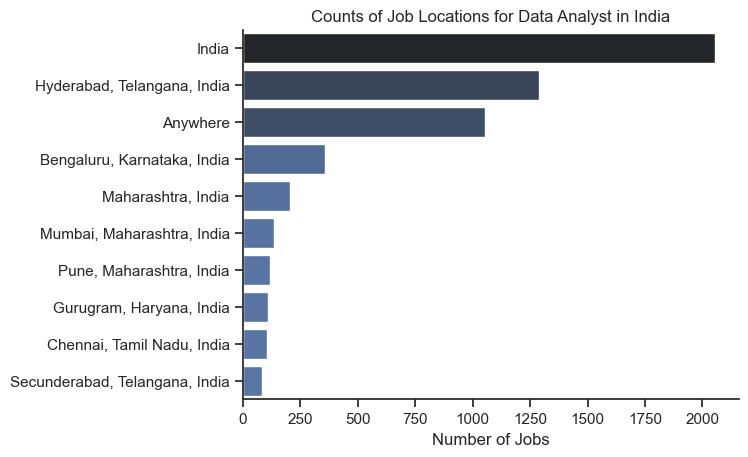

In [ ]:
# Create a DataFrame with the count of job locations for Data Analyst roles in India
df_plot = df_DA_In['job_location'].value_counts().head(10).to_frame() 

sns.set_theme(style='ticks')
sns.barplot(data=df_plot, x='count', y='job_location', hue='count', palette='dark:b_r', legend=False) #
sns.despine()  
plt.title('Counts of Job Locations for Data Analyst in India')  # Set the title of the plot
plt.xlabel('Number of Jobs')                                    # Set the x-axis label
plt.ylabel('')                                                  # Set the y-axis label
plt.show() 

Since the plot is not visually effective, I am filtering the data to display only States.

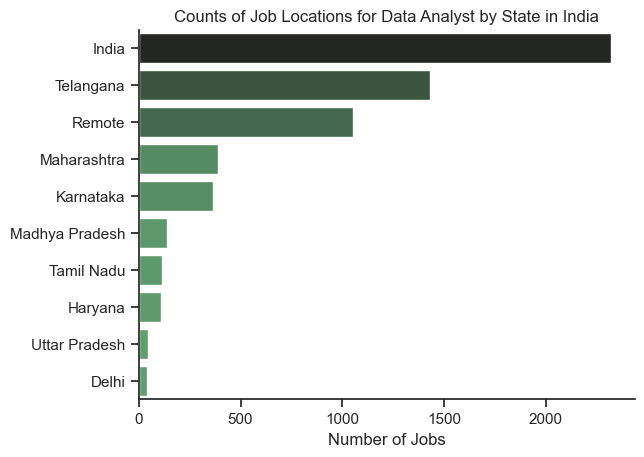

In [9]:
# Extract state names from job_location
df_DA_In = df_DA_In.copy()

df_states = df_DA_In['job_location'].str.split(',', expand=True)

# The second column (index=1) usually contains the state
df_DA_In['state'] = df_states[1].str.strip()

# Handle cases like "India" or "Anywhere"
df_DA_In['state'] = df_DA_In['state'].fillna(df_DA_In['job_location'])
df_DA_In['state'] = df_DA_In['state'].replace({
    'India': 'India',
    'Anywhere': 'Remote'
})

# Count top states
df_plot = df_DA_In['state'].value_counts().head(10).reset_index()
df_plot.columns = ['state', 'count']

# Plotting
sns.set_theme(style='ticks')
sns.barplot(data=df_plot, x='count', y='state', hue='count', palette='dark:g_r', legend=False)
sns.despine()
plt.title('Counts of Job Locations for Data Analyst by State in India')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()

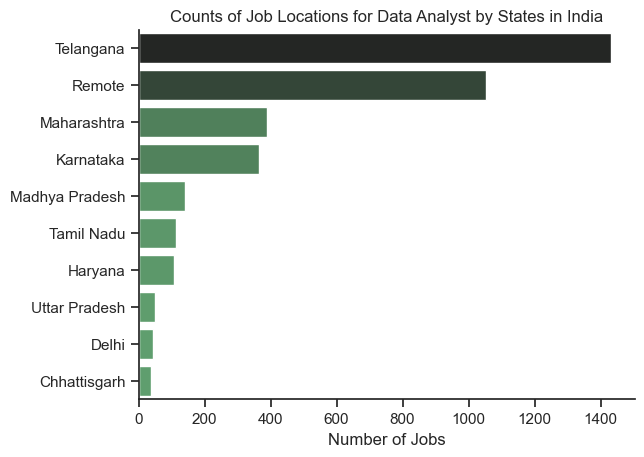

In [10]:
df_DA_In = df_DA_In.copy()

df_states = df_DA_In['job_location'].str.split(',', expand=True)

# If there are 3 parts (e.g., City, State, Country), the state is at index 1
# If there are fewer, it's likely just "India" or "Anywhere"
df_DA_In['state'] = df_states[1].str.strip() if 1 in df_states.columns else None

# Fill remaining missing values with the original location for fallback
df_DA_In['state'] = df_DA_In['state'].fillna(df_DA_In['job_location'])

# Map specific values to clean classifications
df_DA_In['state'] = df_DA_In['state'].replace({
    'India': 'State Unspecified',
    'Anywhere': 'Remote'
})

# Filter out 'State Unspecified' if you only want to visualize actual states/remote options
df_plot = df_DA_In[df_DA_In['state'] != 'State Unspecified']['state'].value_counts().head(10).reset_index()
df_plot.columns = ['state', 'count']

# Plotting
sns.set_theme(style='ticks')
sns.barplot(data=df_plot, x='count', y='state', hue='count', palette='dark:g_r', legend=False)
sns.despine()
plt.title('Counts of Job Locations for Data Analyst by States in India')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show() 

Companies for Data Analyst in India.

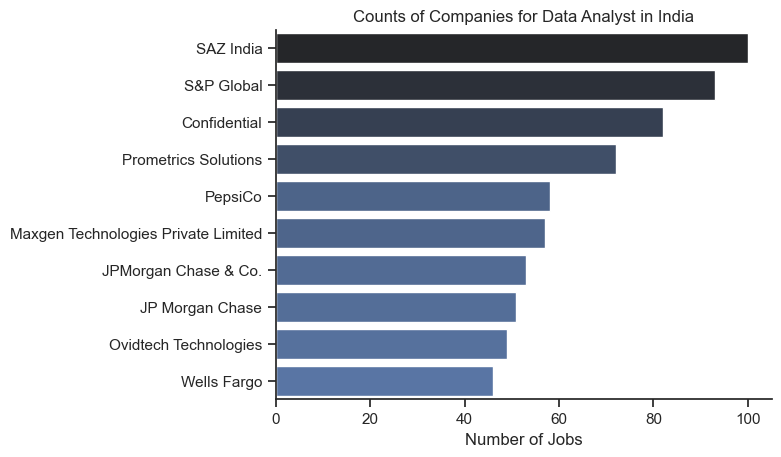

In [11]:
df_plot = df_DA_In['company_name'].value_counts().head(10).to_frame()

sns.set_theme(style='ticks')
sns.barplot(data=df_plot, x='count', y='company_name', hue='count', palette='dark:b_r', legend=False)
sns.despine()
plt.title('Counts of Companies for Data Analyst in India')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()

I filtered the data to see how many jobs offer work-from-home options and require a degree.

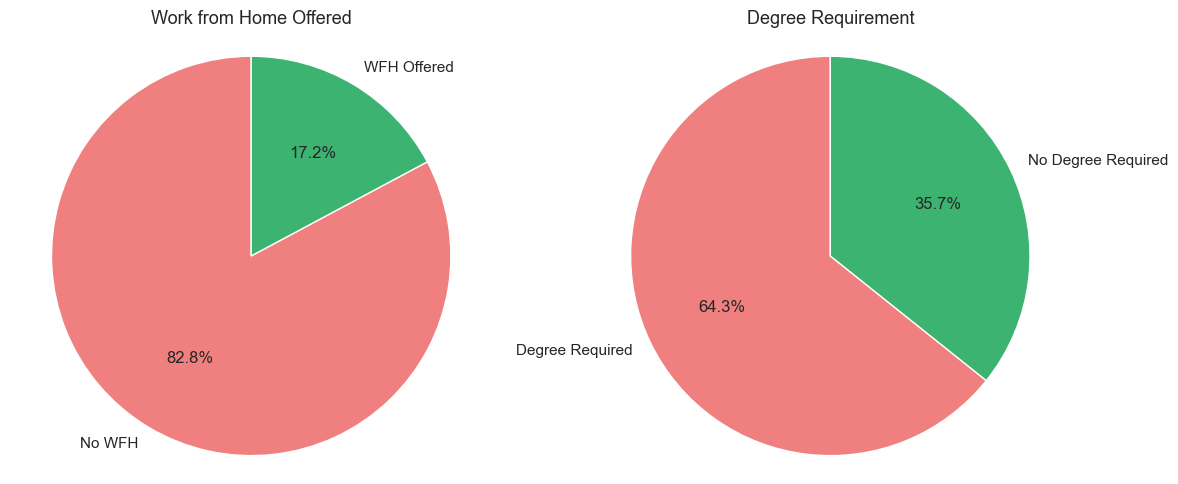

In [12]:
dict_column = {
    'job_work_from_home': 'Work from Home Offered',
    'job_no_degree_mention': 'Degree Requirement'
}

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

for i, (column, title) in enumerate(dict_column.items()):
    # Force the order to always be [False, True] so colors stay consistent
    counts = df_DA_In[column].value_counts().reindex([False, True], fill_value=0)

    # Optional: Map True/False to nicer human-readable text labels
    if column == 'job_work_from_home':
        labels = ['No WFH', 'WFH Offered']
    else:
        # Note: True means "no degree mention" (Degree NOT required)
        labels = ['Degree Required', 'No Degree Required']

    # Now 'lightcoral' always maps to False, and 'mediumseagreen' always maps to True
    colors = ['lightcoral', 'mediumseagreen']

    ax[i].pie(counts, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
    ax[i].set_title(title, fontsize=13, pad=10)
    ax[i].axis('equal')

plt.tight_layout()
plt.show()